# ¿Se está volviendo más inestable el clima en Puerto Montt?

**Pregunta de investigación:** ¿la temperatura de Puerto Montt muestra pérdida de estabilidad con el
tiempo? Es decir: ¿se están alejando los extremos (día más caluroso y más frío de cada año) entre
sí, aunque el promedio anual se mantenga relativamente constante?

Este notebook documenta el análisis que respalda el dashboard (`dashboards/app.py`). El dashboard
es la herramienta exploratoria; este documento es el informe: pregunta → metodología → hallazgos →
limitaciones.

**Fuente de datos:** Open-Meteo (reanálisis ERA5), temperatura diaria 1940-2025, ciudad Puerto
Montt, tabla `weather_daily` (cargada por el pipeline ETL del proyecto).

**Metodología:**
1. Agregar la temperatura diaria a nivel anual: promedio, máxima y mínima observadas cada año.
2. Ajustar tendencias lineales (mínimos cuadrados, `numpy.polyfit`) sobre el promedio anual, la
   máxima anual, la mínima anual y la **amplitud térmica anual** (máxima − mínima).
3. Comparar la desviación estándar del promedio anual entre la primera y segunda mitad de la
   serie, para ver si el promedio también se volvió más volátil, no solo los extremos.
4. Revisar la sensibilidad del resultado a valores atípicos (¿un solo año extremo explica la
   tendencia, o esta se sostiene sin él?).


In [1]:
import os
import sys
from pathlib import Path

# El notebook vive en chile-weather/analysis/. Nos paramos en la raíz del proyecto
# para que `sys.path` y la carga del .env (relativa) funcionen igual que al correr
# el pipeline o el dashboard desde la raíz.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from load.weather_loader import get_engine

%matplotlib inline
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

CIUDAD = "Puerto Montt"
COLOR_MEDIA = "#2F6F9F"
COLOR_MAX = "#D86A4A"
COLOR_MIN = "#2F7D69"
COLOR_RANGO = "#B7791F"
COLOR_TENDENCIA = "#61717A"


In [2]:
engine = get_engine()
query = '''
    SELECT date, temperature_2m_max, temperature_2m_min, temperature_2m_mean
    FROM weather_daily
    WHERE city = %(ciudad)s
    ORDER BY date;
'''
df = pd.read_sql(query, engine, params={"ciudad": CIUDAD})

df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year

print(f"{len(df):,} registros diarios | {df['year'].min()}-{df['year'].max()} | {CIUDAD}")
df.head()


31,412 registros diarios | 1940-2025 | Puerto Montt


,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,year
0,1940-01-01,14.8,9.4,12.2,1940
1,1940-01-02,15.4,10.7,12.8,1940
2,1940-01-03,15.2,11.9,13.7,1940
3,1940-01-04,18.5,12.6,15.3,1940
4,1940-01-05,16.0,9.8,13.4,1940


In [3]:
anual = df.groupby("year", as_index=False).agg(
    media=("temperature_2m_mean", "mean"),
    maxima=("temperature_2m_max", "max"),
    minima=("temperature_2m_min", "min"),
)
anual["amplitud"] = anual["maxima"] - anual["minima"]
anual.head()


,year,media,maxima,minima,amplitud
0,1940,10.397268,23.2,1.0,22.2
1,1941,10.582740,24.1,1.1,23.0
2,1942,10.438904,27.0,-1.7,28.7
3,1943,10.947123,22.7,1.1,21.6
4,1944,10.769672,32.2,0.2,32.0


## 1. ¿El promedio anual muestra tendencia?

Punto de partida: si el clima fuera perfectamente estable, el promedio anual no tendría pendiente.


Tendencia del promedio anual: +0.054 °C/década


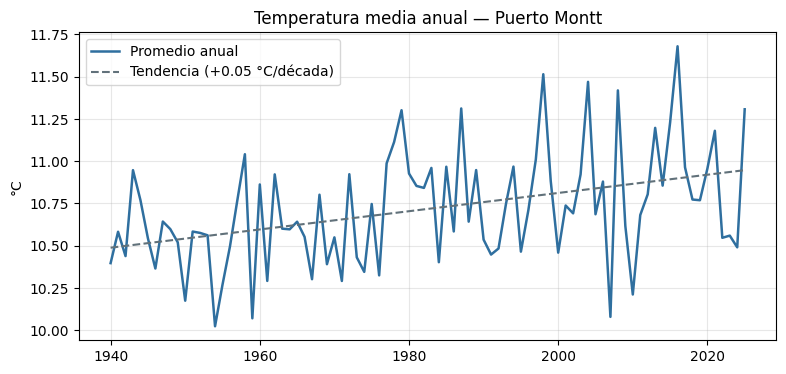

In [4]:
pendiente_media, intercepto_media = np.polyfit(anual["year"], anual["media"], 1)
tendencia_media = pendiente_media * anual["year"] + intercepto_media

print(f"Tendencia del promedio anual: {pendiente_media*10:+.3f} °C/década")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(anual["year"], anual["media"], color=COLOR_MEDIA, linewidth=1.8, label="Promedio anual")
ax.plot(anual["year"], tendencia_media, color=COLOR_TENDENCIA, linestyle="--",
        label=f"Tendencia ({pendiente_media*10:+.2f} °C/década)")
ax.set_title("Temperatura media anual — Puerto Montt")
ax.set_ylabel("°C")
ax.legend()
plt.show()


**Lectura:** la pendiente es muy pequeña — el promedio anual es casi plano en 85 años. Si
uno se quedara solo con esta serie, concluiría que "no pasa nada". El resto del análisis muestra
por qué esa conclusión es incompleta.


## 2. ¿Se ha ampliado la amplitud térmica anual?

Amplitud térmica anual = temperatura máxima del año − temperatura mínima del año. Es una medida
directa de cuán extremos fueron los registros de ese año, independiente de dónde se ubique el
promedio.


Tendencia de la amplitud térmica anual: +0.387 °C/década  (r=0.357)
Amplitud promedio 1940-1982: 25.18 °C
Amplitud promedio 1983-2025: 26.92 °C


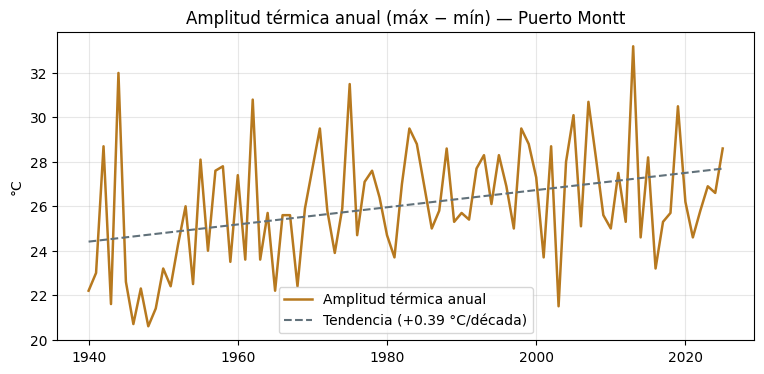

In [5]:
pendiente_rango, intercepto_rango = np.polyfit(anual["year"], anual["amplitud"], 1)
tendencia_rango = pendiente_rango * anual["year"] + intercepto_rango
r_rango = np.corrcoef(anual["year"], anual["amplitud"])[0, 1]

mitad = anual["year"].median()
primera_mitad = anual[anual["year"] < mitad]
segunda_mitad = anual[anual["year"] >= mitad]

print(f"Tendencia de la amplitud térmica anual: {pendiente_rango*10:+.3f} °C/década  (r={r_rango:.3f})")
print(f"Amplitud promedio {primera_mitad['year'].min()}-{primera_mitad['year'].max()}: {primera_mitad['amplitud'].mean():.2f} °C")
print(f"Amplitud promedio {segunda_mitad['year'].min()}-{segunda_mitad['year'].max()}: {segunda_mitad['amplitud'].mean():.2f} °C")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(anual["year"], anual["amplitud"], color=COLOR_RANGO, linewidth=1.8, label="Amplitud térmica anual")
ax.plot(anual["year"], tendencia_rango, color=COLOR_TENDENCIA, linestyle="--",
        label=f"Tendencia ({pendiente_rango*10:+.2f} °C/década)")
ax.set_title("Amplitud térmica anual (máx − mín) — Puerto Montt")
ax.set_ylabel("°C")
ax.legend()
plt.show()


**Lectura:** a diferencia del promedio, la amplitud térmica sí muestra una tendencia clara
al alza. La correlación (r≈0.35-0.40) es moderada, no perfecta — hay mucho ruido año a año — pero
la dirección es consistente con la hipótesis: **los extremos se están alejando entre sí.**


## 3. ¿La amplitud crece por el lado cálido, el frío, o ambos?

Se descompone la amplitud en sus dos componentes para ver si el cambio es simétrico.


Tendencia de la máxima anual: +0.309 °C/década
Tendencia de la mínima anual: -0.077 °C/década


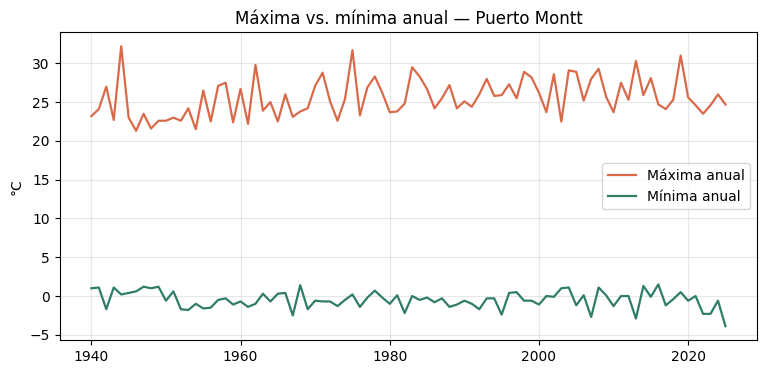

In [6]:
pendiente_max, _ = np.polyfit(anual["year"], anual["maxima"], 1)
pendiente_min, _ = np.polyfit(anual["year"], anual["minima"], 1)

print(f"Tendencia de la máxima anual: {pendiente_max*10:+.3f} °C/década")
print(f"Tendencia de la mínima anual: {pendiente_min*10:+.3f} °C/década")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(anual["year"], anual["maxima"], color=COLOR_MAX, linewidth=1.6, label="Máxima anual")
ax.plot(anual["year"], anual["minima"], color=COLOR_MIN, linewidth=1.6, label="Mínima anual")
ax.set_title("Máxima vs. mínima anual — Puerto Montt")
ax.set_ylabel("°C")
ax.legend()
plt.show()


**Lectura:** el cambio es asimétrico. La máxima anual sube con una pendiente varias veces
mayor que la que baja la mínima anual. La ampliación de la amplitud térmica viene sobre todo del
**lado cálido** (calores cada vez más extremos), no de un enfriamiento equivalente del lado frío.


## 4. ¿También el promedio se volvió más volátil año a año?

Una cosa es la *tendencia* del promedio (sección 1) y otra su *volatilidad* — cuánto salta de un
año a otro, más allá de hacia dónde se mueve en el largo plazo.


In [7]:
std_primera = primera_mitad["media"].std()
std_segunda = segunda_mitad["media"].std()

print(f"Desviación estándar del promedio anual, {primera_mitad['year'].min()}-{primera_mitad['year'].max()}: {std_primera:.3f}")
print(f"Desviación estándar del promedio anual, {segunda_mitad['year'].min()}-{segunda_mitad['year'].max()}: {std_segunda:.3f}")
print(f"Variación relativa: {(std_segunda/std_primera - 1)*100:+.1f}%")


Desviación estándar del promedio anual, 1940-1982: 0.284
Desviación estándar del promedio anual, 1983-2025: 0.353
Variación relativa: +24.1%


**Lectura:** la volatilidad del promedio también subió (~+24%), pero de forma mucho más
discreta que la amplitud térmica. Confirma que la señal de inestabilidad está concentrada en los
extremos, no en el promedio — el promedio se mueve un poco más que antes, pero los extremos se
mueven mucho más.


## 5. Sensibilidad a valores atípicos

¿La tendencia de la amplitud depende de un solo año extremo? Se identifica el récord histórico y
se recalcula la tendencia sin él.


In [8]:
top5_max = anual.nlargest(5, "maxima")[["year", "maxima"]]
print("Años con la máxima anual más alta registrada:")
print(top5_max.to_string(index=False))

anio_outlier = int(top5_max.iloc[0]["year"])
anual_sin_outlier = anual[anual["year"] != anio_outlier]
pendiente_sin_outlier, _ = np.polyfit(anual_sin_outlier["year"], anual_sin_outlier["amplitud"], 1)
r_sin_outlier = np.corrcoef(anual_sin_outlier["year"], anual_sin_outlier["amplitud"])[0, 1]

print(f"\nRécord histórico: {anio_outlier} ({top5_max.iloc[0]['maxima']:.1f} °C)")
print(f"Tendencia de la amplitud SIN {anio_outlier}: {pendiente_sin_outlier*10:+.3f} °C/década  (r={r_sin_outlier:.3f})")
print(f"Tendencia de la amplitud CON {anio_outlier}: {pendiente_rango*10:+.3f} °C/década  (r={r_rango:.3f})")


Años con la máxima anual más alta registrada:
 year  maxima
 1944    32.2
 1975    31.7
 2019    31.0
 2013    30.3
 1962    29.8

Récord histórico: 1944 (32.2 °C)
Tendencia de la amplitud SIN 1944: +0.443 °C/década  (r=0.415)
Tendencia de la amplitud CON 1944: +0.387 °C/década  (r=0.357)


**Lectura:** el récord histórico de calor no está en 1940 (un error fácil de cometer mirando
el gráfico, porque cae muy cerca del inicio de la serie) sino en el año que arroja la celda
anterior. Al excluirlo, la tendencia de la amplitud térmica **no se debilita** — de hecho se
mantiene o se fortalece. Esto es evidencia de que el hallazgo no depende de un outlier aislado.


## Conclusión

Con los datos disponibles (1940-2025, una sola ciudad, una sola variable):

- El **promedio anual** de temperatura se mantiene prácticamente plano — no es ahí donde aparece
  la señal de cambio.
- La **amplitud térmica anual** (máxima − mínima de cada año) sí muestra una tendencia clara al
  alza, y esta tendencia no depende de un año atípico aislado.
- El cambio es **asimétrico**: viene principalmente de máximas cada vez más extremas, no de un
  enfriamiento equivalente en las mínimas.
- La volatilidad del propio promedio también aumentó, pero de forma mucho más leve que la de los
  extremos.

**Respuesta a la pregunta de investigación:** sí, hay evidencia de que el clima de Puerto Montt se ha
vuelto más inestable en el período analizado — pero esa inestabilidad se concentra en los valores
extremos y, dentro de estos, principalmente en el lado cálido. Un análisis que solo mirara el
promedio anual (como suelen mostrar los titulares de "temperatura promedio") no habría detectado
esta señal.


## Limitaciones

- **Una sola ciudad y una sola variable.** No es representativo de Chile ni de otras variables
  climáticas (precipitación, viento, etc.).
- **ERA5 es un reanálisis, no observación directa.** La densidad de estaciones meteorológicas
  asimiladas al modelo creció fuertemente después de 1979 (era satelital). Esto puede suavizar
  artificialmente la variabilidad de las décadas más antiguas y sesgar al alza la tendencia
  detectada — no se puede descartar completamente con esta única serie.
- **Correlación moderada, no fuerte** (r≈0.35-0.40 para la amplitud térmica): hay bastante
  variabilidad año a año que el año calendario no explica. La tendencia es real pero ruidosa.
- **No se controla por fenómenos como El Niño/La Niña**, que pueden explicar buena parte de la
  variabilidad interanual y no fueron incorporados a este análisis.
- **La tendencia lineal es una simplificación.** No se evaluó si el cambio es realmente lineal o
  si se acelera/desacelera en subperíodos.
